# 2026-09-08 HII-traced $\Sigma_{\rm SFR}$: occupancy and surviving-SF intensity

This standalone notebook connects the strict-S/N SF/ND/NSF occupancy analysis to
the resolved SF relation.  At fixed $\log\Sigma_\star$ (primary) and $R/R_e$
(supporting check), it separates the change in HII-traced SFR surface density
over usable disc area into:

1. **occupancy** -- the fraction of usable area that remains in the adopted SF
   selection, $f_{\rm SF}$; and
2. **survivor intensity** -- the linear mean $\Sigma_{\rm SFR}$ conditional on
   the HII-region state under equal-galaxy usable-area weighting.

For this observational decomposition only, ND and NSF pixels contribute zero
*HII-dominated* SFR.  This is not a claim that NSF has zero true SFR.


## 1. Configuration and provenance

Product discovery, geometry, valid-disc masks, and the SF definition are copied
from the live 2026-09-04 fraction notebook.  The denominator is then restricted
with the same strict finite `SNR_POSTFIT > 25` cut.


In [1]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
DATA_ROOT = PROJECT_ROOT / "v3tk_v7.6.8"
CATALOG_PATH = PROJECT_ROOT / "mauve_master_wiki_newclass.fits"
GEOMETRY_PATH = PROJECT_ROOT / "MAUVE_effective_radii.csv"

MASS_FILE_PATTERN = "{galid}_spatial_binning_maps_further.fits"
SFR_FILE_PATTERNS = (
    "{galid}_gas_bin_maps_further.fits",
    "{galid}_gas_BIN_maps_further.fits",
)
EW_FILE_PATTERNS = (
    "{galid}_proxy_EW_maps_further.fits",
    "{galid}_proxy_EW_maps.fits",
)
MASK_FILE_PATTERN = "{galid}_mask.fits"
SFH_FILE_PATTERN = "{galid}_sfh_maps.fits"

MASS_HDU = "LOGMASS_SURFACE_DENSITY"
BIN_HDU_MASS = "BINID"
BIN_HDU_GAS = "BIN_ID"
SFR_HDU = "LOGSFR_SURFACE_DENSITY_HII"
# All-spaxel ordinate only; SFR_HDU remains the original SF-selection map.
ALL_SFR_HDU = "LOGSFR_SURFACE_DENSITY"
EW_HDU = "PROXY_EWHA"
HALPHA_SIGMA_OBS_HDU = "HA6562_SIGMA"
HALPHA_SIGMA_CORR_HDU = "HA6562_SIGMA_CORR"
MASK_TABLE_HDU = "MASKFILE"
MASK_COLUMN = "MASK"
SFH_SNR_POSTFIT_HDU = "SNR_POSTFIT"

EW_HA_MIN = 6.0
HALPHA_SIGMA_MAX = 45.0
SFH_SNR_POSTFIT_MIN = 25.0
I_MAX_PRIMARY = 80.0
MIN_VALID_PIXELS_PER_BIN = 50
MIN_SF_PIXELS_PER_BIN = 20
WCS_TOLERANCE_ARCSEC = 0.05

SIGMA_BIN_WIDTH = 0.25
RADIUS_BIN_WIDTH = 0.25
MASS_CONTOUR_LEVEL = 7.5

mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.grid": False,
})

print(f"Project root: {PROJECT_ROOT}")
print("Scope: HII-traced Sigma_SFR occupancy/intensity across all three infall stages")
print("No additional inclination correction is applied to either surface-density map.")

# Keep category colours fixed across galaxies; these encode categories, not identity.
BALMER_LINES = ("HB4861", "HA6562")
LINE_LABELS = (r"H$\beta$", r"H$\alpha$")
CATEGORY_COLORS = {"SF": "#2166ac", "ND": "#e69f00", "NSF": "#b2182b"}
REASON_LABELS = (
    "BPT: stable non-HII", "BPT: weak/ambiguous/unavailable", "HII SFR unavailable",
    "EW unavailable", "EW <= 6", "Dispersion unavailable", "Dispersion >= 45",
)
REASON_COLORS = ("#b2182b", "#984ea3", "#999999", "#a6cee3", "#33a02c", "#cab2d6", "#e66101")


N_BOOTSTRAP = 10_000
RANDOM_SEED = 42
MIN_RELIABLE_GALAXIES = 3
MIN_RELIABLE_GALAXY_FRACTION = 0.50
MIN_SF_PIXELS_FOR_SUPPORT = MIN_SF_PIXELS_PER_BIN
STAGE_COLORS = {
    "pre-peak": "#2166ac",
    "close-to-peak": "#1a9850",
    "post-peak": "#d73027",
}
COMPONENT_COLORS = {
    "occupancy": "#2166ac",
    "survivor_intensity": "#e69f00",
    "total_hii": "#111111",
}


Project root: /Users/Igniz/Desktop/ICRAR/further
Scope: HII-traced Sigma_SFR occupancy/intensity across all three infall stages
No additional inclination correction is applied to either surface-density map.


## 2. Shared masks and map loaders

The SF mask remains finite `LOGSFR_SURFACE_DENSITY_HII`, EW(Halpha)>6 Angstrom,
and intrinsic Halpha dispersion <45 km/s inside the unchanged valid disc.
ND/NSF are retained for accounting consistency but are not reinterpreted here.


In [2]:
def normalise_stage_label(value) -> str:
    mapping = {
        1: "pre-peak", 1.0: "pre-peak", "1": "pre-peak",
        2: "close-to-peak", 2.0: "close-to-peak", "2": "close-to-peak",
        3: "post-peak", 3.0: "post-peak", "3": "post-peak",
        "prepeak": "pre-peak", "pre-peak": "pre-peak",
        "close-to-peak": "close-to-peak", "closetopeak": "close-to-peak",
        "near-peak": "close-to-peak", "postpeak": "post-peak", "post-peak": "post-peak",
    }
    key = value if isinstance(value, (int, float)) else str(value).strip().lower().replace(" ", "")
    if key not in mapping:
        raise ValueError(f"Unrecognised RPS/infall stage label: {value!r}")
    return mapping[key]


def first_existing(paths):
    for path in paths:
        for candidate in (path, Path(str(path) + ".gz")):
            if candidate.exists():
                return candidate
    return None


def load_fits_map(path: Path, hdu_name: str, *, return_header: bool = False):
    with fits.open(path, memmap=True) as hdul:
        names = {hdu.name.upper() for hdu in hdul}
        if hdu_name.upper() not in names:
            raise KeyError(f"{path}: missing HDU {hdu_name}; available={sorted(names)}")
        hdu = hdul[hdu_name]
        data = np.asarray(hdu.data, dtype=float).copy()
        header = hdu.header.copy()
    return (data, header) if return_header else data


def load_ngist_mask(path: Path, shape):
    with fits.open(path, memmap=True) as hdul:
        if MASK_TABLE_HDU not in hdul:
            raise KeyError(f"{path}: missing table HDU {MASK_TABLE_HDU}")
        table = hdul[MASK_TABLE_HDU].data
        if MASK_COLUMN not in table.names:
            raise KeyError(f"{path}: missing mask column {MASK_COLUMN}; available={table.names}")
        flat = np.asarray(table[MASK_COLUMN], dtype=int)
    if flat.size != int(np.prod(shape)):
        raise ValueError(f"{path}: mask length {flat.size} cannot reshape to {shape}")
    return flat.reshape(shape)


def celestial_wcs_separation_arcsec(header_a, header_b, shape):
    wa, wb = WCS(header_a).celestial, WCS(header_b).celestial
    if not wa.has_celestial or not wb.has_celestial:
        return np.inf
    ny, nx = shape
    x = np.array([0, nx - 1, 0, nx - 1, (nx - 1) / 2])
    y = np.array([0, 0, ny - 1, ny - 1, (ny - 1) / 2])
    raa, deca = wa.pixel_to_world_values(x, y)
    rab, decb = wb.pixel_to_world_values(x, y)
    cosd = np.cos(np.deg2rad((deca + decb) / 2))
    return float(np.nanmax(np.hypot((raa - rab) * cosd, deca - decb)) * 3600.0)


def tangent_offsets_arcsec(ra_deg, dec_deg, ra0_deg, dec0_deg):
    ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
    ra0, dec0 = np.deg2rad(float(ra0_deg)), np.deg2rad(float(dec0_deg))
    dra = (ra - ra0 + np.pi) % (2 * np.pi) - np.pi
    cosc = np.sin(dec0) * np.sin(dec) + np.cos(dec0) * np.cos(dec) * np.cos(dra)
    with np.errstate(divide="ignore", invalid="ignore"):
        east = np.cos(dec) * np.sin(dra) / cosc
        north = (np.cos(dec0) * np.sin(dec) - np.sin(dec0) * np.cos(dec) * np.cos(dra)) / cosc
    return east * 206264.806247, north * 206264.806247


def calculate_deprojected_radius(shape, header, component_rows: pd.DataFrame):
    # Minimum elliptical R/Re over the physical components of one product.
    wcs = WCS(header).celestial
    if not wcs.has_celestial:
        raise ValueError("No celestial WCS available for radius calculation")
    yy, xx = np.indices(shape, dtype=float)
    ra, dec = wcs.pixel_to_world_values(xx, yy)
    radius = np.full(shape, np.inf, dtype=float)
    for _, component in component_rows.iterrows():
        east, north = tangent_offsets_arcsec(
            ra, dec, component.center_ra_deg, component.center_dec_deg
        )
        pa = np.deg2rad(float(component.pa_deg_east_of_north))
        major = east * np.sin(pa) + north * np.cos(pa)
        minor = east * np.cos(pa) - north * np.sin(pa)
        component_radius = np.sqrt(
            (major / float(component.a_re_arcsec)) ** 2
            + (minor / float(component.b_re_arcsec)) ** 2
        )
        radius = np.minimum(radius, component_radius)
    radius[~np.isfinite(radius)] = np.nan
    return radius


def intrinsic_sigma_from_maps(sigma_obs, sigma_corr):
    sigma2 = np.asarray(sigma_obs, dtype=float) ** 2 - np.asarray(sigma_corr, dtype=float) ** 2
    result = np.full(sigma2.shape, np.nan, dtype=float)
    valid = np.isfinite(sigma2) & (sigma2 > 0)
    result[valid] = np.sqrt(sigma2[valid])
    return result


def load_galaxy_maps(row, geometry):
    mass, mass_header = load_fits_map(row.mass_path, MASS_HDU, return_header=True)
    mass_bin = load_fits_map(row.mass_path, BIN_HDU_MASS)
    gas_bin, gas_header = load_fits_map(row.sfr_path, BIN_HDU_GAS, return_header=True)
    sfr = load_fits_map(row.sfr_path, SFR_HDU)
    ew_ha = load_fits_map(row.ew_path, EW_HDU)
    sigma_obs = load_fits_map(row.sfr_path, HALPHA_SIGMA_OBS_HDU)
    sigma_corr = load_fits_map(row.sfr_path, HALPHA_SIGMA_CORR_HDU)
    snr_postfit = load_fits_map(row.sfh_path, SFH_SNR_POSTFIT_HDU)
    shapes = {a.shape for a in (
        mass, mass_bin, gas_bin, sfr, ew_ha, sigma_obs, sigma_corr, snr_postfit
    )}
    if len(shapes) != 1:
        raise ValueError(f"{row.GALID}: map shape mismatch {sorted(shapes)}")
    wcs_sep = celestial_wcs_separation_arcsec(mass_header, gas_header, mass.shape)
    if not np.isfinite(wcs_sep) or wcs_sep > WCS_TOLERANCE_ARCSEC:
        raise ValueError(f"{row.GALID}: mass/gas WCS mismatch {wcs_sep:.4f} arcsec")
    ngist_mask = load_ngist_mask(row.mask_path, mass.shape)
    components = geometry.loc[geometry.notebook_product_id.eq(row.GALID)].copy()
    radius_re = calculate_deprojected_radius(mass.shape, mass_header, components)
    sigma_intrinsic = intrinsic_sigma_from_maps(sigma_obs, sigma_corr)
    valid = (
        np.isfinite(mass) & np.isfinite(gas_bin) & (ngist_mask == 0) & np.isfinite(radius_re)
    )
    sf = (
        valid & np.isfinite(sfr) & np.isfinite(ew_ha) & (ew_ha > EW_HA_MIN)
        & np.isfinite(sigma_intrinsic) & (sigma_intrinsic < HALPHA_SIGMA_MAX)
    )
    maps = {
        "log_sigma_star": mass,
        "log_sigma_sfr": sfr,
        "radius_re": radius_re,
        "snr_postfit": snr_postfit,
        "valid_disc_mask": valid,
        "sf_mask": sf,
        "mass_header": mass_header,
        "wcs_separation_arcsec": wcs_sep,
    }
    return add_detection_categories(maps, row, ew_ha, sigma_intrinsic)


def binned_fraction(values, valid_mask, selected_mask, edges, min_valid=MIN_VALID_PIXELS_PER_BIN):
    rows = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        in_bin = np.isfinite(values) & (values >= lo) & (values < hi)
        n_valid = int((valid_mask & in_bin).sum())
        n_selected = int((selected_mask & in_bin).sum())
        rows.append({
            "center": (lo + hi) / 2,
            "N_valid": n_valid,
            "N_SF": n_selected,
            "f_SF": n_selected / n_valid if n_valid >= min_valid else np.nan,
        })
    return pd.DataFrame(rows)


def radial_mass_trends(maps, edges):
    radius = maps["radius_re"]
    mass = maps["log_sigma_star"]
    rows = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        in_bin = np.isfinite(radius) & (radius >= lo) & (radius < hi)
        all_pixels = maps["valid_disc_mask"] & in_bin
        sf_pixels = maps["sf_mask"] & in_bin
        n_all, n_sf = int(all_pixels.sum()), int(sf_pixels.sum())
        rows.append({
            "radius_center": (lo + hi) / 2,
            "N_all": n_all,
            "N_SF": n_sf,
            "all_median": np.nanmedian(mass[all_pixels]) if n_all >= MIN_VALID_PIXELS_PER_BIN else np.nan,
            "sf_median": np.nanmedian(mass[sf_pixels]) if n_sf >= MIN_SF_PIXELS_PER_BIN else np.nan,
        })
    return pd.DataFrame(rows)

def add_detection_categories(maps, row, ew_ha, sigma_intrinsic):
    """Use Balmer-only ND and preserve the original SF selection exactly."""
    valid, sf = maps["valid_disc_mask"], maps["sf_mask"]
    detected = {}
    invalid_any = np.zeros(valid.shape, dtype=bool)
    with fits.open(row.sfr_path, memmap=True) as hdul:
        header = hdul[0].header
        sn_cut, flux_floor = float(header["CUT_SN"]), float(header["NOISE"])
        if not (np.isfinite(sn_cut) and sn_cut > 0 and np.isfinite(flux_floor) and flux_floor > 0):
            raise ValueError(f"{row.GALID}: invalid detection thresholds")
        if str(header["BPTMODE"]).strip().lower() != "both":
            raise ValueError(f"{row.GALID}: expected the original both-BPT selection")
        for line in BALMER_LINES:
            flux = np.asarray(hdul[line + "_FLUX"].data, dtype=float)
            error = np.asarray(hdul[line + "_FLUX_ERR"].data, dtype=float)
            if flux.shape != valid.shape or error.shape != valid.shape:
                raise ValueError(f"{row.GALID}: {line} shape mismatch")
            measurable = np.isfinite(flux) & np.isfinite(error) & (error > 0)
            invalid_any |= ~measurable
            with np.errstate(divide="ignore", invalid="ignore"):
                detected[line] = measurable & (flux / error >= sn_cut) & (flux >= flux_floor)
        # Do not use the old NII_HA_BPT / SII_HA_BPT ratio HDUs as class maps.
        nii = np.asarray(hdul["NII_BPT"].data).copy()
        sii = np.asarray(hdul["SII_BPT"].data).copy()
        for name, arr in (("NII_BPT", nii), ("SII_BPT", sii)):
            if arr.shape != valid.shape or not np.isin(arr[valid], [-1, 0, 1, 2, 3]).all():
                raise ValueError(f"{row.GALID}: invalid {name} class map")
        provenance = {key: header.get(key, "not recorded")
                      for key in ("CUT_SN", "NOISE", "BPTMODE", "BPTLIMIT", "DUSTLAW")}
    balmer_detected = detected["HA6562"] & detected["HB4861"]
    if np.any(sf & ~balmer_detected):
        raise AssertionError(f"{row.GALID}: original SF includes a Balmer non-detection")
    nd = valid & ~balmer_detected
    nsf = valid & balmer_detected & ~sf
    # Exclusive bookkeeping, in this order: HII gate -> EW gate -> sigma gate.
    # This is a first-failed-gate decomposition, not a unique physical cause.
    has_sfr = np.isfinite(maps["log_sigma_sfr"])
    stable_non_hii = np.isin(nii, [2, 3]) | np.isin(sii, [2, 3])
    both_hii = (nii == 1) & (sii == 1)
    conditions = (
        ~has_sfr & stable_non_hii,
        ~has_sfr & ~both_hii,
        ~has_sfr,
        ~np.isfinite(ew_ha),
        ew_ha <= EW_HA_MIN,
        ~np.isfinite(sigma_intrinsic),
        sigma_intrinsic >= HALPHA_SIGMA_MAX,
    )
    remainder = nsf.copy()
    reasons = {}
    for label, condition in zip(REASON_LABELS, conditions):
        reasons[label] = remainder & condition
        remainder &= ~condition
    if remainder.any():
        raise AssertionError(f"{row.GALID}: unexplained detected non-SF pixels")
    category_sum = sf.astype(np.int8) + nd + nsf
    assert np.array_equal(category_sum, valid.astype(np.int8))
    assert np.array_equal(np.sum(list(reasons.values()), axis=0), nsf.astype(int))
    maps.update({
        "nd_mask": nd, "nsf_mask": nsf, "balmer_detected_mask": balmer_detected,
        "line_detected": detected, "nsf_reasons": reasons,
        "nd_invalid_mask": nd & invalid_any,
        "nd_measured_below_cut_mask": nd & ~invalid_any,
        "detection_provenance": provenance,
    })
    return maps


def binned_categories(values, maps, edges):
    result = binned_fraction(values, maps["valid_disc_mask"], maps["sf_mask"], edges)
    for label, key in (("ND", "nd_mask"), ("NSF", "nsf_mask")):
        extra = binned_fraction(values, maps["valid_disc_mask"], maps[key], edges)
        result["N_" + label] = extra.N_SF
        result["f_" + label] = extra.f_SF
    assert np.array_equal(result.N_SF + result.N_ND + result.N_NSF, result.N_valid)
    shown = result.N_valid >= MIN_VALID_PIXELS_PER_BIN
    assert np.allclose(result.loc[shown, ["f_SF", "f_ND", "f_NSF"]].sum(axis=1), 1)
    assert int(result.N_valid.sum()) == int(maps["valid_disc_mask"].sum())
    return result


def plot_category_fractions(axis, table):
    for label, linestyle in (("SF", "-"), ("ND", "--"), ("NSF", "-.")):
        axis.plot(table.center, table["f_" + label], marker="o", ms=3, lw=1.8,
                  ls=linestyle, color=CATEGORY_COLORS[label], label=r"$f_{\rm " + label + "}$")
    axis.legend(fontsize=8, ncol=3, loc="best")


## 3. Live three-stage inventory and quality control

The notebook keeps only QC-passing products and does not replace missing
post-peak systems with older or partial files.


In [3]:
def read_master_catalogue(path):
    with fits.open(path) as hdul:
        table = hdul[1].data
        frame = pd.DataFrame({
            "galaxy": [str(value).strip() for value in table["Galaxy"]],
            "logMstar": np.asarray(table["logMstar"], dtype=float),
            "stage_code": np.asarray(table["class"], dtype=float),
        })
    frame["stage"] = frame.stage_code.map(normalise_stage_label)
    return frame


def discover_products(data_root):
    rows = []
    for folder in sorted(path for path in data_root.iterdir()
                         if path.is_dir() and not path.name.endswith("_logs")):
        galid = folder.name
        rows.append({
            "GALID": galid,
            "mass_path": folder / MASS_FILE_PATTERN.format(galid=galid),
            "sfr_path": first_existing([
                folder / pattern.format(galid=galid) for pattern in SFR_FILE_PATTERNS
            ]),
            "ew_path": first_existing([
                folder / pattern.format(galid=galid) for pattern in EW_FILE_PATTERNS
            ]),
            "mask_path": folder / MASK_FILE_PATTERN.format(galid=galid),
            "sfh_path": first_existing([
                folder / SFH_FILE_PATTERN.format(galid=galid)
            ]),
        })
    return pd.DataFrame(rows)


STAGE_ORDER = ("pre-peak", "close-to-peak", "post-peak")
PANEL_ORDER = STAGE_ORDER + ("all stages",)
STAGE_LABELS = {
    "pre-peak": "Pre-peak",
    "close-to-peak": "Close-to-peak",
    "post-peak": "Post-peak",
    "all stages": "All stages",
}

master = read_master_catalogue(CATALOG_PATH)
geometry = pd.read_csv(GEOMETRY_PATH)
required_geometry = {
    "galaxy", "notebook_product_id", "mauve_infall_stage", "center_ra_deg",
    "center_dec_deg", "inclination_deg", "pa_deg_east_of_north",
    "a_re_arcsec", "b_re_arcsec",
}
missing_geometry = required_geometry - set(geometry.columns)
if missing_geometry:
    raise KeyError(f"{GEOMETRY_PATH}: missing columns {sorted(missing_geometry)}")

geometry = geometry.merge(
    master[["galaxy", "logMstar", "stage"]], on="galaxy", how="left",
    validate="one_to_one",
)
geometry["stage_from_geometry"] = geometry.mauve_infall_stage.map(normalise_stage_label)
if not geometry.stage.eq(geometry.stage_from_geometry).all():
    raise RuntimeError("Stage disagreement between the master and effective-radius catalogues")

product_meta = []
for galid, group in geometry.groupby("notebook_product_id", sort=False):
    if group.stage.nunique() != 1:
        raise RuntimeError(f"{galid}: physical components have inconsistent stages")
    product_meta.append({
        "GALID": galid,
        "components": ",".join(group.galaxy),
        "stage": group.stage.iloc[0],
        "inclination": float(group.inclination_deg.max()),
    })

inventory = pd.DataFrame(product_meta).merge(
    discover_products(DATA_ROOT), on="GALID", how="left", validate="one_to_one"
)
candidates = inventory.loc[
    inventory.stage.isin(STAGE_ORDER) & inventory.inclination.lt(I_MAX_PRIMARY)
].sort_values(["stage", "GALID"]).reset_index(drop=True)

# This first pass performs full live QC and records only range/count summaries.
# Maps are not cached so the combined notebook does not retain all galaxies in memory.
qc_rows = []
for row in candidates.itertuples(index=False):
    flags = []
    for label, path in (("mass", row.mass_path), ("sfr", row.sfr_path),
                        ("ew", row.ew_path), ("mask", row.mask_path),
                        ("sfh", row.sfh_path)):
        if not isinstance(path, Path) or not path.exists():
            flags.append(f"missing_{label}_product")
    maps = None
    if not flags:
        try:
            maps = load_galaxy_maps(row, geometry)
            valid = maps["valid_disc_mask"]
            if np.any(maps["sf_mask"] & ~valid):
                flags.append("sf_not_subset_of_valid")
        except Exception as exc:
            flags.append(f"load_error:{type(exc).__name__}:{exc}")
    if maps is not None and not flags:
        valid = maps["valid_disc_mask"]
        category_total = (
            maps["sf_mask"].astype(np.int8)
            + maps["nd_mask"].astype(np.int8)
            + maps["nsf_mask"].astype(np.int8)
        )
        if not np.array_equal(category_total, valid.astype(np.int8)):
            flags.append("category_accounting_failure")
    qc_rows.append({
        "GALID": row.GALID,
        "components": row.components,
        "stage": row.stage,
        "inclination_deg": row.inclination,
        "N_valid": int(valid.sum()) if maps is not None and not flags else 0,
        "N_SF": int(maps["sf_mask"].sum()) if maps is not None and not flags else 0,
        "sigma_min": float(np.nanmin(maps["log_sigma_star"][valid]))
                     if maps is not None and not flags else np.nan,
        "sigma_max": float(np.nanmax(maps["log_sigma_star"][valid]))
                     if maps is not None and not flags else np.nan,
        "radius_min": float(np.nanmin(maps["radius_re"][valid]))
                      if maps is not None and not flags else np.nan,
        "radius_max": float(np.nanmax(maps["radius_re"][valid]))
                      if maps is not None and not flags else np.nan,
        "wcs_separation_arcsec": maps["wcs_separation_arcsec"]
                                if maps is not None and not flags else np.nan,
        "QC_flag": ";".join(flags) if flags else "OK",
    })
    del maps

SAMPLE_QC = pd.DataFrame(qc_rows)
passed_ids = set(SAMPLE_QC.loc[SAMPLE_QC.QC_flag.eq("OK"), "GALID"])
sample = candidates.loc[candidates.GALID.isin(passed_ids)].copy()

display(SAMPLE_QC)
display(SAMPLE_QC.groupby(["stage", "QC_flag"], observed=True).size().rename("N_galaxies"))
for stage in STAGE_ORDER:
    n_pass = int(sample.stage.eq(stage).sum())
    n_candidate = int(candidates.stage.eq(stage).sum())
    print(f"{STAGE_LABELS[stage]}: {n_pass}/{n_candidate} products pass QC")
    if n_pass == 0:
        raise RuntimeError(f"No {stage} galaxies passed the live product QC")
print(f"Total passing products: {len(sample)}/{len(candidates)}")


Pre-peak: 8/8 products pass QC
Close-to-peak: 5/5 products pass QC
Post-peak: 13/16 products pass QC
Total passing products: 26/29


,GALID,components,stage,inclination_deg,N_valid,N_SF,sigma_min,sigma_max,radius_min,radius_max,wcs_separation_arcsec,QC_flag
0,NGC4298,NGC4298,close-to-peak,52.0,498540,144157,6.476232,9.372817,0.002597,2.927309,0.0,OK
1,NGC4424,NGC4424,close-to-peak,61.0,172561,8994,7.113861,9.027295,0.002721,2.533259,0.0,OK
2,NGC4501,NGC4501,close-to-peak,65.0,664236,251936,6.926827,10.916401,0.002436,2.862775,0.0,OK
3,NGC4654,NGC4654,close-to-peak,61.0,659231,345036,6.043689,9.750619,0.000637,2.836630,0.0,OK
4,NGC4694,NGC4694,close-to-peak,62.0,94538,1058,6.934593,9.479634,0.004544,3.796772,0.0,OK
5,IC3392,IC3392,post-peak,68.0,94575,13897,6.969276,9.253759,0.004326,3.084733,0.0,OK
6,NGC4064,NGC4064,post-peak,70.0,179882,3273,6.811374,9.428892,0.002945,1.939061,0.0,OK
7,NGC4293,NGC4293,post-peak,67.0,261523,471,7.243091,10.336573,0.001645,1.842599,0.0,OK
8,NGC4380,NGC4380,post-peak,61.0,502065,64097,6.694095,10.141226,0.001755,2.963534,0.0,OK
9,NGC4394,NGC4394,post-peak,32.0,180654,31915,7.352380,10.783341,0.001999,1.488715,0.0,OK


stage          QC_flag                                                                                             
close-to-peak  OK                                                                                                       5
post-peak      OK                                                                                                      13
               missing_mass_product;missing_sfr_product;missing_ew_product;missing_mask_product;missing_sfh_product     3
pre-peak       OK                                                                                                       8
Name: N_galaxies, dtype: int64

## 4. Per-galaxy measurements in common bins

For galaxy $g$ and bin $b$, after the strict S/N cut:

$$
f_{g,b}=N_{{\rm SF},g,b}/N_{{\rm usable},g,b},\qquad
T_{g,b}=\frac{\sum_{{\rm SF}\;i}\Sigma_{{\rm SFR},i}}
               {N_{{\rm usable},g,b}}.
$$

$T_{g,b}$ is HII-traced SFR surface density averaged over usable area.  The
per-galaxy conditional survivor mean is also stored as a diagnostic.  Bins with
fewer than 50 usable pixels do not enter the stage estimator.


In [4]:
def complete_common_edges(minimum, maximum, width, *, lower_limit=None):
    minimum, maximum, width = float(minimum), float(maximum), float(width)
    start = float(lower_limit) if lower_limit is not None else np.floor(minimum / width) * width
    stop = (np.floor(maximum / width) + 1.0) * width
    edges = np.arange(start, stop + 0.5 * width, width)
    if not (edges[0] <= minimum and edges[-1] > maximum):
        raise AssertionError("Common edges do not enclose the live valid range")
    return edges


passing_qc = SAMPLE_QC.loc[SAMPLE_QC.QC_flag.eq("OK")]
COMMON_EDGES = {
    "log_sigma_star": complete_common_edges(
        passing_qc.sigma_min.min(), passing_qc.sigma_max.max(), SIGMA_BIN_WIDTH
    ),
    "radius_re": complete_common_edges(
        passing_qc.radius_min.min(), passing_qc.radius_max.max(),
        RADIUS_BIN_WIDTH, lower_limit=0.0,
    ),
}
VARIABLE_LABELS = {
    "log_sigma_star": r"$\log_{10}(\Sigma_\star/[M_\odot\,\mathrm{kpc}^{-2}])$",
    "radius_re": r"$R/R_e$",
}

measurement_rows = []
snr_summary_rows = []
all_retained_strict = True
for galaxy_row in sample.itertuples(index=False):
    maps = load_galaxy_maps(galaxy_row, geometry)
    original_valid = maps["valid_disc_mask"]
    snr_postfit = maps["snr_postfit"]
    keep = (
        original_valid & np.isfinite(snr_postfit)
        & (snr_postfit > SFH_SNR_POSTFIT_MIN)
    )
    all_retained_strict &= bool(np.all(snr_postfit[keep] > SFH_SNR_POSTFIT_MIN))
    sf_keep = maps["sf_mask"] & keep
    log_sfr = maps["log_sigma_sfr"]
    if np.any(sf_keep & ~np.isfinite(log_sfr)):
        raise AssertionError(f"{galaxy_row.GALID}: SF mask contains non-finite HII SFR")
    snr_summary_rows.append({
        "GALID": galaxy_row.GALID,
        "stage": galaxy_row.stage,
        "N_valid_original": int(original_valid.sum()),
        "N_valid_retained": int(keep.sum()),
        "N_SF_retained": int(sf_keep.sum()),
    })
    for variable, edges in COMMON_EDGES.items():
        values = maps[variable]
        for lo, hi in zip(edges[:-1], edges[1:]):
            in_bin = np.isfinite(values) & (values >= lo) & (values < hi)
            usable = keep & in_bin
            sf = sf_keep & in_bin
            n_usable = int(usable.sum())
            n_sf = int(sf.sum())
            linear_sfr = np.power(10.0, log_sfr[sf])
            if linear_sfr.size and (
                not np.isfinite(linear_sfr).all() or np.any(linear_sfr <= 0)
            ):
                raise AssertionError(f"{galaxy_row.GALID}: invalid linear Sigma_SFR")
            sum_sfr = float(linear_sfr.sum())
            eligible = n_usable >= MIN_VALID_PIXELS_PER_BIN
            f_sf = n_sf / n_usable if eligible else np.nan
            total_area_hii = sum_sfr / n_usable if eligible else np.nan
            survivor_mean = sum_sfr / n_sf if n_sf > 0 else np.nan
            measurement_rows.append({
                "GALID": galaxy_row.GALID,
                "stage": galaxy_row.stage,
                "variable": variable,
                "bin_left": float(lo),
                "bin_right": float(hi),
                "center": float((lo + hi) / 2),
                "N_usable": n_usable,
                "N_SF": n_sf,
                "eligible_usable": bool(eligible),
                "survivor_support": bool(n_sf >= MIN_SF_PIXELS_FOR_SUPPORT),
                "f_SF": f_sf,
                "sum_Sigma_SFR_SF": sum_sfr,
                "mean_Sigma_SFR_SF_galaxy": survivor_mean,
                "mean_Sigma_SFR_all_HII_galaxy": total_area_hii,
            })
    del maps

SFR_BY_GALAXY_BIN = pd.DataFrame(measurement_rows)
SFR_SNR_SUMMARY = pd.DataFrame(snr_summary_rows)
STAGE_TOTAL_GALAXIES = {
    stage: int(sample.loc[sample.stage.eq(stage), "GALID"].nunique())
    for stage in STAGE_ORDER
}
assert all_retained_strict
assert set(SFR_BY_GALAXY_BIN.GALID) == set(sample.GALID)
print("Strict-S/N retained sample by stage")
display(SFR_SNR_SUMMARY.groupby("stage").agg(
    N_galaxies=("GALID", "nunique"),
    N_valid_retained=("N_valid_retained", "sum"),
    N_SF_retained=("N_SF_retained", "sum"),
).reindex(STAGE_ORDER))


Strict-S/N retained sample by stage


,N_galaxies,N_valid_retained,N_SF_retained
stage,,,
pre-peak,8,2703316,1420915
close-to-peak,5,1643790,720842
post-peak,13,2825159,222427


## 5. Equal-galaxy usable-area estimator and support

For a stage/bin with $G$ eligible galaxies, define

$$
O=\frac{1}{G}\sum_g f_g,\qquad
T=\frac{1}{G}\sum_g T_g,\qquad
I=\frac{T}{O}.
$$

$O$ is SF occupancy, $T$ is the equal-galaxy mean HII-traced SFR per usable
area, and $I$ is the corresponding conditional survivor intensity.  Therefore
$T=O\,I$ exactly.  This conditional intensity weights each galaxy's SF emission
by its SF occupancy while retaining equal galaxy weight in the total-area
quantity.

The common decomposition range requires, in every stage, at least three galaxies
and at least half the stage with usable-bin support, plus at least three galaxies
with 20 or more surviving SF pixels.  Full-range support remains visible in the
audit figure.


In [5]:
def stage_sfr_estimator(per_galaxy):
    rows = []
    keys = ["stage", "variable", "bin_left", "bin_right", "center"]
    for group_keys, group in per_galaxy.groupby(keys, observed=True, sort=False):
        rec = dict(zip(keys, group_keys))
        stage = rec["stage"]
        eligible = group.loc[group.eligible_usable].copy()
        n_stage = STAGE_TOTAL_GALAXIES[stage]
        rec.update({
            "N_gal_stage": n_stage,
            "N_gal_usable": int(eligible.GALID.nunique()),
            "N_gal_any_SF": int(eligible.loc[eligible.N_SF.gt(0), "GALID"].nunique()),
            "N_gal_SF_support": int(eligible.loc[eligible.survivor_support, "GALID"].nunique()),
            "N_spaxel_usable": int(eligible.N_usable.sum()),
            "N_spaxel_SF": int(eligible.N_SF.sum()),
        })
        rec["f_gal_usable"] = rec["N_gal_usable"] / n_stage
        rec["f_gal_SF_support"] = rec["N_gal_SF_support"] / n_stage
        rec["occupancy"] = float(eligible.f_SF.mean()) if len(eligible) else np.nan
        rec["total_hii"] = (
            float(eligible.mean_Sigma_SFR_all_HII_galaxy.mean())
            if len(eligible) else np.nan
        )
        rec["survivor_intensity"] = (
            rec["total_hii"] / rec["occupancy"]
            if rec["occupancy"] > 0 else np.nan
        )
        rec["reliable_usable"] = bool(
            rec["N_gal_usable"] >= MIN_RELIABLE_GALAXIES
            and rec["f_gal_usable"] >= MIN_RELIABLE_GALAXY_FRACTION
        )
        rec["reliable_decomposition"] = bool(
            rec["reliable_usable"]
            and rec["N_gal_SF_support"] >= MIN_RELIABLE_GALAXIES
        )
        rows.append(rec)
    return pd.DataFrame(rows)


def largest_contiguous_common_block(common_rows):
    frame = common_rows.sort_values("bin_left").reset_index(drop=True)
    runs = []
    start = stop = None
    n_bins = 0
    for row in frame.itertuples(index=False):
        contiguous = stop is not None and np.isclose(row.bin_left, stop)
        if row.reliable_common and (start is None or contiguous):
            if start is None:
                start = float(row.bin_left)
                n_bins = 0
            stop = float(row.bin_right)
            n_bins += 1
        else:
            if start is not None:
                runs.append((start, stop, n_bins))
            start = float(row.bin_left) if row.reliable_common else None
            stop = float(row.bin_right) if row.reliable_common else None
            n_bins = 1 if row.reliable_common else 0
    if start is not None:
        runs.append((start, stop, n_bins))
    if not runs:
        raise AssertionError("No common reliable Sigma_SFR decomposition block")
    return max(runs, key=lambda item: (item[2], item[1] - item[0]))


STAGE_SFR_PROFILES = stage_sfr_estimator(SFR_BY_GALAXY_BIN)
common_flags = (
    STAGE_SFR_PROFILES.groupby(
        ["variable", "bin_left", "bin_right", "center"], observed=True
    )
    .agg(
        N_stages=("stage", "nunique"),
        reliable_common=("reliable_decomposition", "all"),
    )
    .reset_index()
)
common_flags["reliable_common"] &= common_flags.N_stages.eq(len(STAGE_ORDER))

range_rows = []
COMMON_DECOMPOSITION_RANGES = {}
for variable in ("log_sigma_star", "radius_re"):
    block = largest_contiguous_common_block(
        common_flags.loc[common_flags.variable.eq(variable)]
    )
    COMMON_DECOMPOSITION_RANGES[variable] = (block[0], block[1])
    range_rows.append({
        "variable": variable,
        "fiducial_min": block[0],
        "fiducial_max": block[1],
        "N_contiguous_bins": block[2],
    })
COMMON_DECOMPOSITION_RANGE_TABLE = pd.DataFrame(range_rows)
STAGE_SFR_PROFILES = STAGE_SFR_PROFILES.merge(
    common_flags[
        ["variable", "bin_left", "bin_right", "center", "reliable_common"]
    ],
    on=["variable", "bin_left", "bin_right", "center"],
    how="left", validate="many_to_one",
)
STAGE_SFR_PROFILES["in_fiducial_common_range"] = False
for variable, (lo, hi) in COMMON_DECOMPOSITION_RANGES.items():
    use = STAGE_SFR_PROFILES.variable.eq(variable)
    STAGE_SFR_PROFILES.loc[use, "in_fiducial_common_range"] = (
        STAGE_SFR_PROFILES.loc[use, "center"].ge(lo)
        & STAGE_SFR_PROFILES.loc[use, "center"].lt(hi)
    )

display(COMMON_DECOMPOSITION_RANGE_TABLE)
display(STAGE_SFR_PROFILES[[
    "stage", "variable", "bin_left", "bin_right", "N_gal_usable",
    "f_gal_usable", "N_gal_SF_support", "occupancy",
    "survivor_intensity", "total_hii", "reliable_decomposition",
    "in_fiducial_common_range",
]].round(5))


,variable,fiducial_min,fiducial_max,N_contiguous_bins
0,log_sigma_star,7.5,9.25,7
1,radius_re,0.0,2.00,8


,stage,variable,bin_left,bin_right,N_gal_usable,f_gal_usable,N_gal_SF_support,occupancy,survivor_intensity,total_hii,reliable_decomposition,in_fiducial_common_range
0,close-to-peak,log_sigma_star,5.75,6.00,0,0.0,0,NaN,NaN,NaN,False,False
1,close-to-peak,log_sigma_star,6.00,6.25,0,0.0,0,NaN,NaN,NaN,False,False
2,close-to-peak,log_sigma_star,6.25,6.50,0,0.0,0,NaN,NaN,NaN,False,False
3,close-to-peak,log_sigma_star,6.50,6.75,1,0.2,1,0.79187,0.00137,0.00109,False,False
4,close-to-peak,log_sigma_star,6.75,7.00,1,0.2,1,0.56662,0.00228,0.00129,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
157,pre-peak,radius_re,6.75,7.00,0,0.0,0,NaN,NaN,NaN,False,False
158,pre-peak,radius_re,7.00,7.25,0,0.0,0,NaN,NaN,NaN,False,False
159,pre-peak,radius_re,7.25,7.50,0,0.0,0,NaN,NaN,NaN,False,False
160,pre-peak,radius_re,7.50,7.75,0,0.0,0,NaN,NaN,NaN,False,False


## 6. Whole-galaxy bootstrap and frozen pre-peak comparison

Each bootstrap draw resamples complete galaxies within a stage and recomputes
$O$, $I$, and $T$.  Close-to-peak and post-peak offsets use the central pre-peak
curve as a frozen reference:

$$
\Delta\log T = \Delta\log O + \Delta\log I.
$$

The target-stage 16th--84th percentile envelopes therefore include finite target
galaxy sampling but deliberately exclude uncertainty in the frozen pre-peak
reference.  This convention keeps the reference identical across all target
comparisons and is stated here to prevent over-interpreting the interval.


In [6]:
def bootstrap_stage_profiles(per_galaxy, n_boot=N_BOOTSTRAP):
    summary_rows = []
    draws_by_key = {}
    for stage_index, stage in enumerate(STAGE_ORDER):
        stage_galaxies = (
            sample.loc[sample.stage.eq(stage), "GALID"].sort_values().to_numpy()
        )
        for variable_index, variable in enumerate(("log_sigma_star", "radius_re")):
            edges = COMMON_EDGES[variable]
            stage_frame = per_galaxy.loc[
                per_galaxy.stage.eq(stage) & per_galaxy.variable.eq(variable)
            ]
            for bin_index, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
                group = (
                    stage_frame.loc[np.isclose(stage_frame.bin_left, lo)]
                    .set_index("GALID").reindex(stage_galaxies)
                )
                eligible = group.eligible_usable.fillna(False).to_numpy(bool)
                occupancy_values = np.where(
                    eligible, group.f_SF.to_numpy(float), np.nan
                )
                total_values = np.where(
                    eligible,
                    group.mean_Sigma_SFR_all_HII_galaxy.to_numpy(float),
                    np.nan,
                )
                seed = (
                    RANDOM_SEED + 100_000 * stage_index
                    + 10_000 * variable_index + bin_index
                )
                rng = np.random.default_rng(seed)
                indices = rng.integers(
                    0, len(stage_galaxies), size=(n_boot, len(stage_galaxies))
                )
                occ_sample = occupancy_values[indices]
                total_sample = total_values[indices]
                counts = np.isfinite(occ_sample).sum(axis=1)
                occ_boot = np.divide(
                    np.nansum(occ_sample, axis=1), counts,
                    out=np.full(n_boot, np.nan), where=counts > 0,
                )
                total_boot = np.divide(
                    np.nansum(total_sample, axis=1), counts,
                    out=np.full(n_boot, np.nan), where=counts > 0,
                )
                intensity_boot = np.divide(
                    total_boot, occ_boot,
                    out=np.full(n_boot, np.nan),
                    where=np.isfinite(occ_boot) & (occ_boot > 0),
                )
                key = (stage, variable, float(lo))
                draws_by_key[key] = {
                    "occupancy": occ_boot,
                    "survivor_intensity": intensity_boot,
                    "total_hii": total_boot,
                }
                central = STAGE_SFR_PROFILES.loc[
                    STAGE_SFR_PROFILES.stage.eq(stage)
                    & STAGE_SFR_PROFILES.variable.eq(variable)
                    & np.isclose(STAGE_SFR_PROFILES.bin_left, lo)
                ].iloc[0]
                rec = {
                    "stage": stage, "variable": variable,
                    "bin_left": float(lo), "bin_right": float(hi),
                    "center": float((lo + hi) / 2),
                }
                for metric, values in draws_by_key[key].items():
                    finite = values[np.isfinite(values) & (values > 0)]
                    rec[metric] = float(central[metric])
                    if finite.size:
                        rec[metric + "_lo"], rec[metric + "_hi"] = np.percentile(
                            finite, [16, 84]
                        )
                    else:
                        rec[metric + "_lo"] = np.nan
                        rec[metric + "_hi"] = np.nan
                summary_rows.append(rec)
    return pd.DataFrame(summary_rows), draws_by_key


SFR_BOOTSTRAP, SFR_BOOTSTRAP_DRAWS = bootstrap_stage_profiles(SFR_BY_GALAXY_BIN)
SFR_BOOTSTRAP = SFR_BOOTSTRAP.merge(
    STAGE_SFR_PROFILES[[
        "stage", "variable", "bin_left", "bin_right", "center",
        "N_gal_usable", "N_gal_SF_support", "reliable_decomposition",
        "in_fiducial_common_range",
    ]],
    on=["stage", "variable", "bin_left", "bin_right", "center"],
    how="left", validate="one_to_one",
)

delta_rows = []
for target_stage in ("close-to-peak", "post-peak"):
    target_profiles = SFR_BOOTSTRAP.loc[SFR_BOOTSTRAP.stage.eq(target_stage)]
    for target in target_profiles.itertuples(index=False):
        reference = SFR_BOOTSTRAP.loc[
            SFR_BOOTSTRAP.stage.eq("pre-peak")
            & SFR_BOOTSTRAP.variable.eq(target.variable)
            & np.isclose(SFR_BOOTSTRAP.bin_left, target.bin_left)
        ].iloc[0]
        rec = {
            "stage": target_stage,
            "variable": target.variable,
            "bin_left": target.bin_left,
            "bin_right": target.bin_right,
            "center": target.center,
            "N_gal_usable": target.N_gal_usable,
            "N_gal_SF_support": target.N_gal_SF_support,
            "reliable_decomposition": target.reliable_decomposition,
            "in_fiducial_common_range": target.in_fiducial_common_range,
        }
        target_draws = SFR_BOOTSTRAP_DRAWS[
            (target_stage, target.variable, float(target.bin_left))
        ]
        for metric, out_name in (
            ("occupancy", "delta_log_occupancy"),
            ("survivor_intensity", "delta_log_survivor_intensity"),
            ("total_hii", "delta_log_total_hii"),
        ):
            ref_value = float(reference[metric])
            target_value = float(getattr(target, metric))
            rec[out_name] = (
                np.log10(target_value) - np.log10(ref_value)
                if target_value > 0 and ref_value > 0 else np.nan
            )
            draws = target_draws[metric]
            delta = np.full(draws.shape, np.nan)
            if ref_value > 0:
                positive = np.isfinite(draws) & (draws > 0)
                delta[positive] = np.log10(draws[positive]) - np.log10(ref_value)
            finite = delta[np.isfinite(delta)]
            if finite.size:
                rec[out_name + "_lo"], rec[out_name + "_hi"] = np.percentile(
                    finite, [16, 84]
                )
            else:
                rec[out_name + "_lo"] = np.nan
                rec[out_name + "_hi"] = np.nan
        delta_rows.append(rec)
SFR_DECOMPOSITION = pd.DataFrame(delta_rows)
SFR_DECOMPOSITION["identity_residual_dex"] = (
    SFR_DECOMPOSITION.delta_log_total_hii
    - SFR_DECOMPOSITION.delta_log_occupancy
    - SFR_DECOMPOSITION.delta_log_survivor_intensity
)

print("Stage offsets relative to the frozen central pre-peak reference")
display(SFR_DECOMPOSITION.loc[
    SFR_DECOMPOSITION.in_fiducial_common_range,
    [
        "stage", "variable", "bin_left", "bin_right", "N_gal_usable",
        "N_gal_SF_support", "delta_log_occupancy",
        "delta_log_survivor_intensity", "delta_log_total_hii",
        "identity_residual_dex",
    ],
].round(5))


Stage offsets relative to the frozen central pre-peak reference


,stage,variable,bin_left,bin_right,N_gal_usable,N_gal_SF_support,delta_log_occupancy,delta_log_survivor_intensity,delta_log_total_hii,identity_residual_dex
7,close-to-peak,log_sigma_star,7.50,7.75,5,4,-0.25210,-0.10765,-0.35975,-0.0
8,close-to-peak,log_sigma_star,7.75,8.00,5,4,-0.18044,-0.12148,-0.30192,0.0
9,close-to-peak,log_sigma_star,8.00,8.25,5,5,-0.12732,-0.15344,-0.28076,-0.0
10,close-to-peak,log_sigma_star,8.25,8.50,5,5,-0.02845,-0.13952,-0.16798,0.0
11,close-to-peak,log_sigma_star,8.50,8.75,5,5,0.07668,-0.16432,-0.08764,-0.0
12,close-to-peak,log_sigma_star,8.75,9.00,5,5,0.07315,-0.18904,-0.11590,0.0
13,close-to-peak,log_sigma_star,9.00,9.25,4,4,-0.17101,-0.17325,-0.34426,0.0
22,close-to-peak,radius_re,0.00,0.25,5,5,0.01193,-0.38512,-0.37319,0.0
23,close-to-peak,radius_re,0.25,0.50,5,5,-0.11233,-0.54583,-0.65816,-0.0
24,close-to-peak,radius_re,0.50,0.75,5,5,-0.10073,-0.49177,-0.59249,-0.0


## 7. Coverage and absolute stage profiles

The first figure exposes the full support function.  The absolute profiles then
show the common reliable range only.  Occupancy is dimensionless; survivor and
total HII-traced intensities are plotted in logarithmic surface-density units.


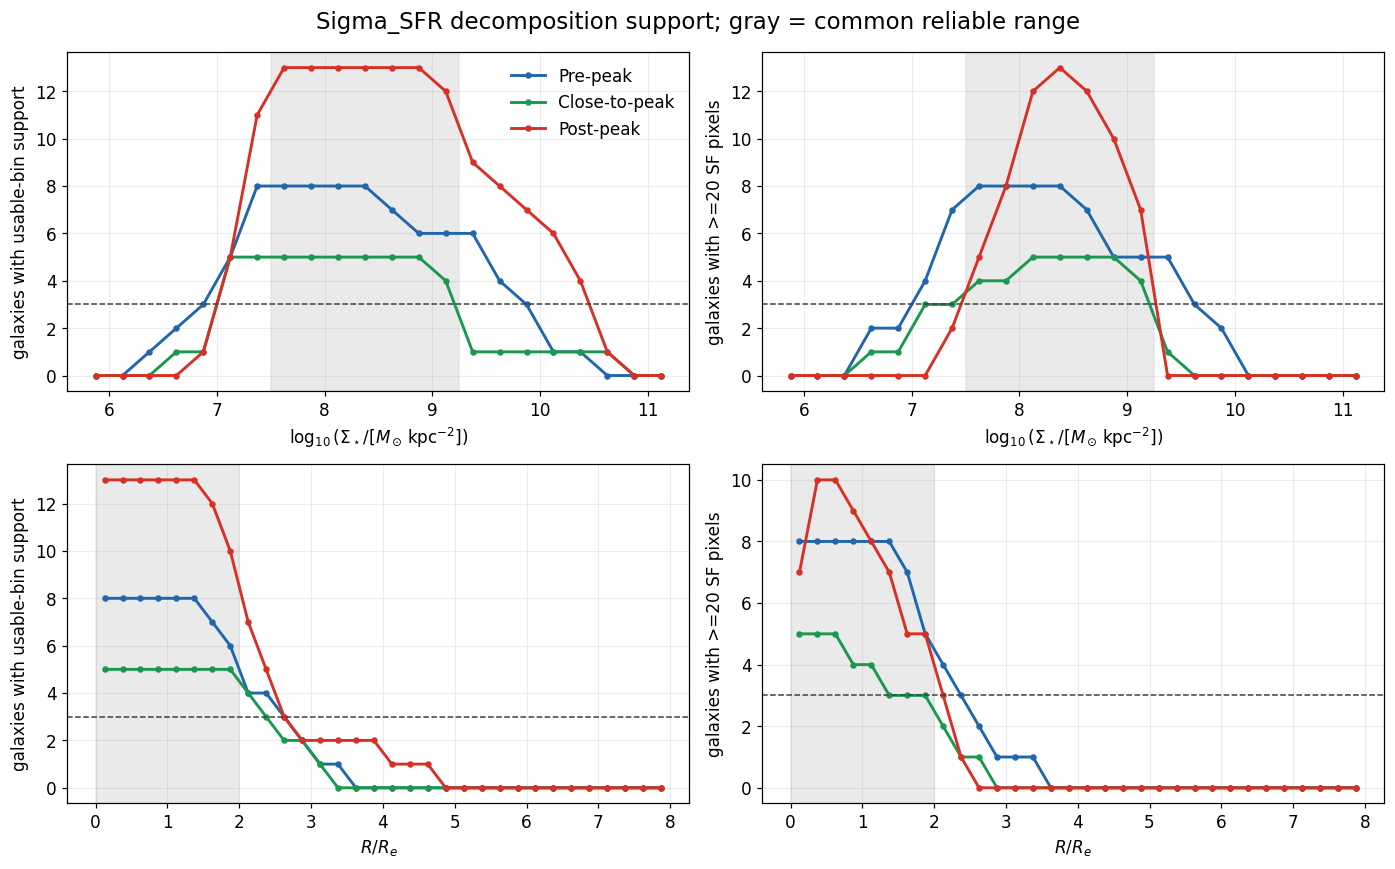

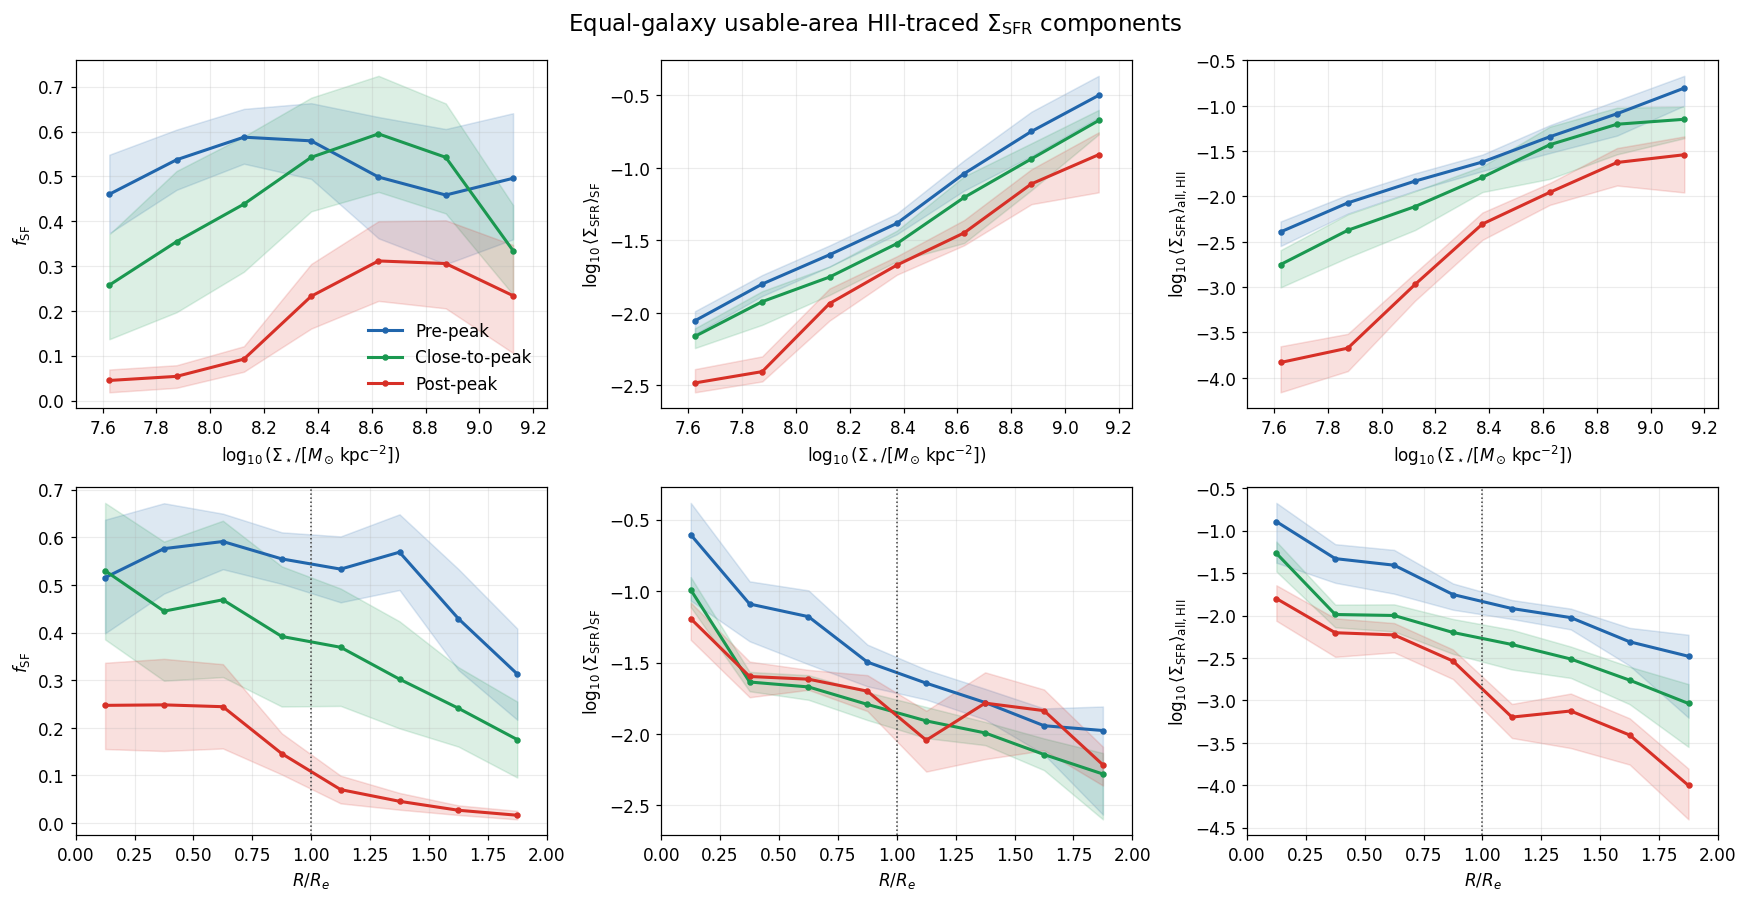

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12.8, 8.0))
for row_index, variable in enumerate(("log_sigma_star", "radius_re")):
    lo, hi = COMMON_DECOMPOSITION_RANGES[variable]
    for column_index, (metric, threshold, ylabel) in enumerate((
        ("N_gal_usable", MIN_RELIABLE_GALAXIES, "galaxies with usable-bin support"),
        ("N_gal_SF_support", MIN_RELIABLE_GALAXIES, "galaxies with >=20 SF pixels"),
    )):
        ax = axes[row_index, column_index]
        for stage in STAGE_ORDER:
            panel = STAGE_SFR_PROFILES.loc[
                STAGE_SFR_PROFILES.stage.eq(stage)
                & STAGE_SFR_PROFILES.variable.eq(variable)
            ].sort_values("center")
            ax.plot(
                panel.center, panel[metric], marker="o", ms=3.2, lw=1.9,
                color=STAGE_COLORS[stage], label=STAGE_LABELS[stage],
            )
        ax.axhline(threshold, color="0.25", ls="--", lw=1.0)
        ax.axvspan(lo, hi, color="0.85", alpha=0.55, zorder=0)
        ax.set_xlabel(VARIABLE_LABELS[variable])
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.23)
        if row_index == 0 and column_index == 0:
            ax.legend(frameon=False)
fig.suptitle("Sigma_SFR decomposition support; gray = common reliable range", fontsize=15)
fig.tight_layout()
plt.show()
plt.close(fig)

fig, axes = plt.subplots(2, 3, figsize=(16.0, 8.3))
absolute_specs = (
    ("occupancy", r"$f_{\rm SF}$", False),
    ("survivor_intensity", r"$\log_{10}\langle\Sigma_{\rm SFR}\rangle_{\rm SF}$", True),
    ("total_hii", r"$\log_{10}\langle\Sigma_{\rm SFR}\rangle_{\rm all,HII}$", True),
)
for row_index, variable in enumerate(("log_sigma_star", "radius_re")):
    lo, hi = COMMON_DECOMPOSITION_RANGES[variable]
    for column_index, (metric, ylabel, take_log) in enumerate(absolute_specs):
        ax = axes[row_index, column_index]
        for stage in STAGE_ORDER:
            panel = SFR_BOOTSTRAP.loc[
                SFR_BOOTSTRAP.stage.eq(stage)
                & SFR_BOOTSTRAP.variable.eq(variable)
                & SFR_BOOTSTRAP.in_fiducial_common_range
            ].sort_values("center")
            x = panel.center.to_numpy(float)
            y = panel[metric].to_numpy(float)
            lower = panel[metric + "_lo"].to_numpy(float)
            upper = panel[metric + "_hi"].to_numpy(float)
            if take_log:
                y, lower, upper = np.log10(y), np.log10(lower), np.log10(upper)
            ax.fill_between(x, lower, upper, color=STAGE_COLORS[stage], alpha=0.15)
            ax.plot(x, y, marker="o", ms=3.2, lw=2.0,
                    color=STAGE_COLORS[stage], label=STAGE_LABELS[stage])
        ax.set_xlim(lo, hi)
        ax.set_xlabel(VARIABLE_LABELS[variable])
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.23)
        if variable == "radius_re":
            ax.axvline(1.0, color="0.25", ls=":", lw=1.0)
        if row_index == 0 and column_index == 0:
            ax.legend(frameon=False)
fig.suptitle(
    r"Equal-galaxy usable-area HII-traced $\Sigma_{\rm SFR}$ components",
    fontsize=15,
)
fig.tight_layout()
plt.show()
plt.close(fig)


## 8. Suppression decomposition relative to pre-peak

The black curve is the total HII-traced change.  Blue and orange show the
occupancy and survivor-intensity terms whose sum is exactly the black curve.
The two target stages are kept separate; the close-to-peak class is not assumed
to be a smooth intermediate population.


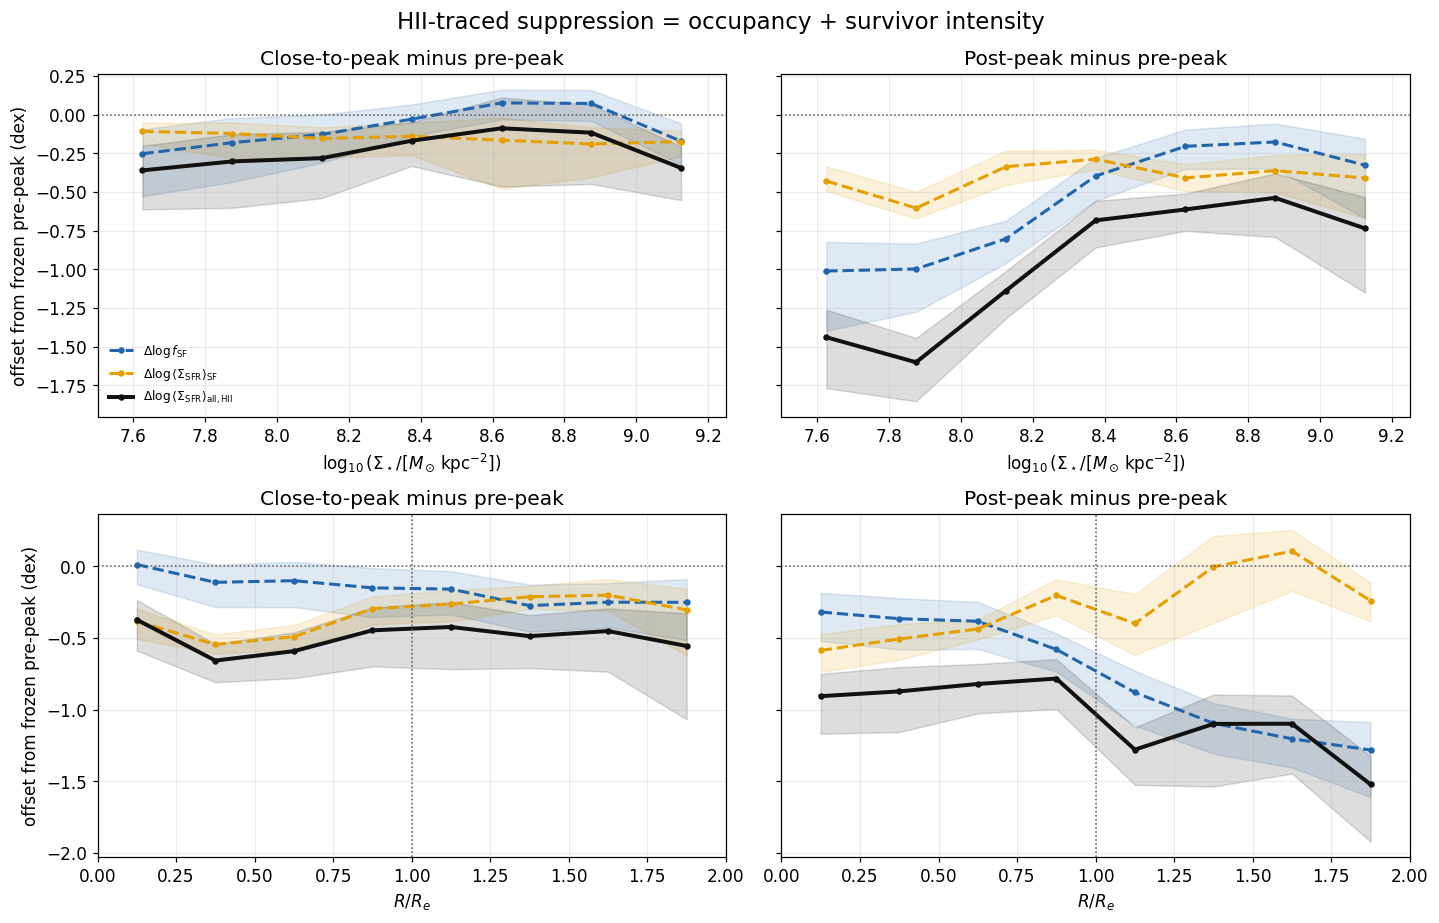

In [8]:
delta_specs = (
    ("delta_log_occupancy", "occupancy"),
    ("delta_log_survivor_intensity", "survivor_intensity"),
    ("delta_log_total_hii", "total_hii"),
)
fig, axes = plt.subplots(2, 2, figsize=(13.2, 8.5), sharey="row")
for row_index, variable in enumerate(("log_sigma_star", "radius_re")):
    lo, hi = COMMON_DECOMPOSITION_RANGES[variable]
    for column_index, stage in enumerate(("close-to-peak", "post-peak")):
        ax = axes[row_index, column_index]
        panel = SFR_DECOMPOSITION.loc[
            SFR_DECOMPOSITION.stage.eq(stage)
            & SFR_DECOMPOSITION.variable.eq(variable)
            & SFR_DECOMPOSITION.in_fiducial_common_range
        ].sort_values("center")
        for column, component in delta_specs:
            x = panel.center.to_numpy(float)
            y = panel[column].to_numpy(float)
            lower = panel[column + "_lo"].to_numpy(float)
            upper = panel[column + "_hi"].to_numpy(float)
            ax.fill_between(x, lower, upper, color=COMPONENT_COLORS[component], alpha=0.14)
            ax.plot(
                x, y, marker="o", ms=3.2,
                lw=2.6 if component == "total_hii" else 2.0,
                ls="-" if component == "total_hii" else "--",
                color=COMPONENT_COLORS[component],
                label={
                    "occupancy": r"$\Delta\log f_{\rm SF}$",
                    "survivor_intensity": r"$\Delta\log\langle\Sigma_{\rm SFR}\rangle_{\rm SF}$",
                    "total_hii": r"$\Delta\log\langle\Sigma_{\rm SFR}\rangle_{\rm all,HII}$",
                }[component],
            )
        ax.axhline(0.0, color="0.35", ls=":", lw=1.0)
        if variable == "radius_re":
            ax.axvline(1.0, color="0.35", ls=":", lw=1.0)
        ax.set_xlim(lo, hi)
        ax.set_xlabel(VARIABLE_LABELS[variable])
        ax.set_title(STAGE_LABELS[stage] + " minus pre-peak")
        ax.grid(alpha=0.23)
        if column_index == 0:
            ax.set_ylabel("offset from frozen pre-peak (dex)")
axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("HII-traced suppression = occupancy + survivor intensity", fontsize=15)
fig.tight_layout()
plt.show()
plt.close(fig)


## 9. Numerical verification and interpretation limits

The checks establish strict selection, the linear and logarithmic identities,
and the support rule.  They do not establish that NSF is DIG, that NSF contains
no star formation, or that stage differences are caused by RPS alone.  Absolute
NSF Halpha emission and excitation diagnostics are the separate create-versus-
reveal analysis proposed next in the source discussion.


In [9]:
per_galaxy_identity = SFR_BY_GALAXY_BIN.loc[
    SFR_BY_GALAXY_BIN.eligible_usable & SFR_BY_GALAXY_BIN.N_SF.gt(0)
].copy()
per_galaxy_identity["reconstructed_total"] = (
    per_galaxy_identity.f_SF
    * per_galaxy_identity.mean_Sigma_SFR_SF_galaxy
)
reliable_delta = SFR_DECOMPOSITION.loc[
    SFR_DECOMPOSITION.in_fiducial_common_range
]
positive_stage_rows = STAGE_SFR_PROFILES.loc[
    STAGE_SFR_PROFILES.occupancy.gt(0)
]
zero_stage_rows = STAGE_SFR_PROFILES.loc[
    STAGE_SFR_PROFILES.occupancy.eq(0)
]
range_support_ok = True
for variable, (lo, hi) in COMMON_DECOMPOSITION_RANGES.items():
    rows = STAGE_SFR_PROFILES.loc[
        STAGE_SFR_PROFILES.variable.eq(variable)
        & STAGE_SFR_PROFILES.center.ge(lo)
        & STAGE_SFR_PROFILES.center.lt(hi)
    ]
    range_support_ok &= bool(
        rows.reliable_decomposition.all()
        and rows.stage.nunique() == len(STAGE_ORDER)
    )

verification = pd.Series({
    "all_retained_spaxels_meet_strict_snr_postfit_gt_25": bool(all_retained_strict),
    "per_galaxy_linear_identity_is_exact": bool(np.allclose(
        per_galaxy_identity.mean_Sigma_SFR_all_HII_galaxy,
        per_galaxy_identity.reconstructed_total,
        rtol=2e-12, atol=0.0,
    )),
    "stage_linear_identity_is_exact_for_positive_occupancy": bool(np.allclose(
        positive_stage_rows.total_hii,
        positive_stage_rows.occupancy * positive_stage_rows.survivor_intensity,
        rtol=2e-12, atol=0.0,
    )),
    "zero_occupancy_has_zero_hii_total": bool(np.allclose(
        zero_stage_rows.total_hii, 0.0, rtol=0.0, atol=0.0
    )),
    "delta_log_identity_is_exact": bool(np.allclose(
        reliable_delta.identity_residual_dex, 0.0, atol=2e-12
    )),
    "every_fiducial_bin_has_common_stage_support": range_support_ok,
    "fiducial_decomposition_is_finite": bool(reliable_delta[[
        "delta_log_occupancy", "delta_log_survivor_intensity",
        "delta_log_total_hii",
    ]].notna().all().all()),
    "frozen_reference_target_intervals_are_finite": bool(reliable_delta[[
        f"{name}_{bound}"
        for name in (
            "delta_log_occupancy", "delta_log_survivor_intensity",
            "delta_log_total_hii",
        )
        for bound in ("lo", "hi")
    ]].notna().all().all()),
}, name="passed")
display(verification)
if not verification.all():
    raise AssertionError("Sigma_SFR decomposition verification failed")
print("SIGMA_SFR_VERIFICATION_OK")


SIGMA_SFR_VERIFICATION_OK


all_retained_spaxels_meet_strict_snr_postfit_gt_25       True
per_galaxy_linear_identity_is_exact                      True
stage_linear_identity_is_exact_for_positive_occupancy    True
zero_occupancy_has_zero_hii_total                        True
delta_log_identity_is_exact                              True
every_fiducial_bin_has_common_stage_support              True
fiducial_decomposition_is_finite                         True
frozen_reference_target_intervals_are_finite             True
Name: passed, dtype: bool

## Reading the result

- The survivor-intensity term is the rSFMS-like, SF-conditioned change.  The
  occupancy term quantifies the additional loss hidden when only surviving SF
  spaxels are analysed.
- The total term is explicitly **HII-traced** SFR over usable area.  It is not a
  bolometric or multi-wavelength total-SFR estimate.
- The primary comparison is at fixed $\log\Sigma_\star$; radius is a structural
  cross-check and does not independently control stellar mass.
- Whole-galaxy resampling respects the galaxy as the independent unit.  The small
  close-to-peak sample and the frozen-reference convention must remain visible in
  any paper-level interpretation.
- This notebook does not answer whether inner NSF emission is created or revealed.
  That requires absolute NSF Halpha surface brightness and excitation/kinematic
  diagnostics at fixed $(\Sigma_\star,R/R_e)$.
